In [24]:
import pandas as pd
from src.network import de_am
from ergochemics.standardize import hash_reaction, standardize_rxn
from ergochemics.draw import draw_reaction
from IPython.display import SVG, display
from minedatabase.pickaxe import Pickaxe

In [22]:
pk = Pickaxe()
pk.load_pickled_pickaxe("/home/stef/quest_data/bottle/data/raw/2_steps_ccm_aa_to_None_rules_mechinferred_dt_13_rules_w_coreactants_co_metacyc_coreactants_sampled_False_pruned_False_aplusb_True.pk")
pyruvate = [v for k, v in pk.compounds.items() if v['ID'] == 'pyruvate'][0]
pyruvate

----------------------------------------
Intializing pickaxe object

Done intializing pickaxe object
----------------------------------------

Loading /home/stef/quest_data/bottle/data/raw/2_steps_ccm_aa_to_None_rules_mechinferred_dt_13_rules_w_coreactants_co_metacyc_coreactants_sampled_False_pruned_False_aplusb_True.pk pickled data.
Loaded 61480 compounds
Loaded 138825 reactions
Loaded 7635 operators
Loaded 70 coreactants
Loaded 2 generation
Took 2.3655521869659424


[16:27:42] WARNING: not removing hydrogen atom without neighbors


{'ID': 'pyruvate',
 '_id': 'Cf7e036e330ad26caa66bb458faad18fa684af921',
 'SMILES': 'CC(=O)C(=O)O',
 'InChI_key': 'LCTONWCANYUPML-UHFFFAOYSA-N',
 'Type': 'Starting Compound',
 'Generation': 0,
 'atom_count': Counter({'H': 4, 'C': 3, 'O': 3}),
 'Reactant_in': ['...'],
 'Product_of': ['Rc076782398f407c3d751a62f3ee7709c0a476028a52de8342aa062d4b660259f',
  'Raa8be4208a8b75922ab2a9930d44ec331df9b043f2307247330c05782c4dbc4d',
  'Rbb0cffd1dc514103415482512f5dea0f9d50ffc75649c30e0696f91cdd3dbf83',
  'R3a85fcfc2fb27452bab8c9b2372d232524f8b1fb2bbd4511bb07b17ea3c72fc9',
  'Rede8585659823e68d5d39a6730a5963bec90fa2217498c48babf3352d8781f94',
  'R81d370d0fbe2b888a7aa6d4d43f007c50d232376ed649c8b3ab9fae773bcca1d',
  'R1b784b85dcb6b708fc63ff0eaa5a3a1f2877fe10791a8f0c0d7a731cf89e0b8b',
  'Rbded29c960bff4e6d193c5da69ca1870896ed5bf4404fca46f99aff0dd766446',
  'R446bd366f991cf24494684a1aa53699d7b6fe9adfa3de5c8e35e6755905eb6b8',
  'Rce2815814a81a6968e545baec977e932c022864e40ad9dac3e5f7c095e9f2ba2',
  'R46d2c

R8867459e4201138c2d6ff7989ea3f1b352f599fb4f9035702a8dd66abeb5984e


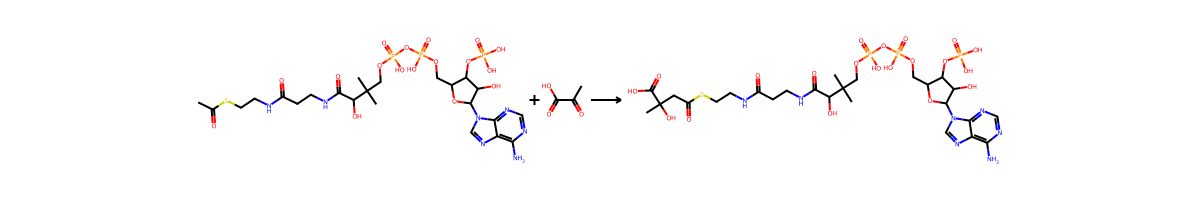

In [35]:
rxns = {}
for old_id in pyruvate['Reactant_in']:
    rxn = pk.reactions[old_id]
    std_rxn = standardize_rxn(rxn['Operator_aligned_smarts'])
    rid = hash_reaction(std_rxn)
    if rid == '5582845919356f447668dd0ea4647fbddf01b7ac':
        print(old_id)
        display(SVG(draw_reaction(rxn['Operator_aligned_smarts'])))
    rxns[rid] = std_rxn

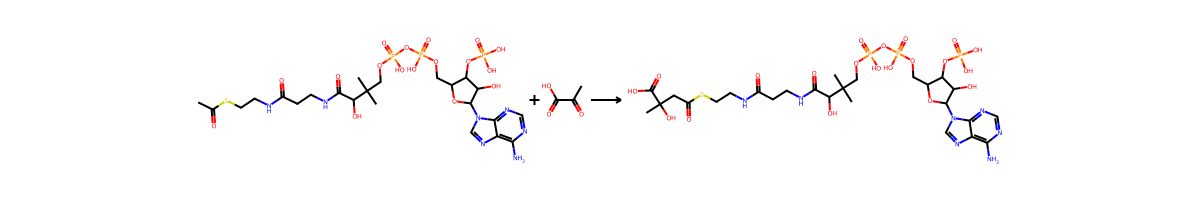

In [31]:
SVG(draw_reaction(rxns['5582845919356f447668dd0ea4647fbddf01b7ac']))

In [7]:
dir = '/home/stef/quest_data/bottle/data/interim/expansions/lin_test'
r = pd.read_parquet(f'{dir}/am_rxns.parquet')
r.head()

,smarts,am_smarts,rules,half_expansion,size
0,NC(CCC(=O)O)C(=O)O>>CC(C(=O)O)C(N)C(=O)O,[NH2:1][CH:2]([CH2:3][CH2:4][C:5](=[O:6])[OH:7...,[mechinferred_dt_13:5008],forward,9
1,CC(CC(=O)SCCNC(=O)CCNC(=O)C(O)C(C)(C)COP(=O)(O...,[CH3:3][CH:2]([CH2:1][C:7](=[O:8])[S:9][CH2:10...,[mechinferred_dt_04:3939],forward,5
2,NC(=O)C1=CN(C2OC(COP(=O)(O)OP(=O)(O)OCC3OC(n4c...,[NH2:58][C:59](=[O:60])[C:61]1=[CH:105][N:65](...,[mechinferred_dt_04:6695],forward,15
3,CC(O)(CC(=O)SCCNC(=O)CCNC(=O)C(O)C(C)(C)COP(=O...,[CH3:1][C:2]([OH:3])([CH2:4][C:5](=[O:6])[S:7]...,"[mechinferred_dt_13:2441, mechinferred_dt_13:9...",forward,8
4,NC(=O)C1=CN(C2OC(COP(=O)(O)OP(=O)(O)OCC3OC(n4c...,[NH2:105][C:106](=[O:107])[C:108]1=[CH:152][N:...,"[mechinferred_dt_04:4272, mechinferred_dt_04:1...",forward,26


In [3]:
len(r)

8

In [9]:
rids = []
for sma in r['am_smarts']:
    lhl, rhl = de_am(sma)
    de_am_sma = f"{".".join(lhl)}>>{".".join(rhl)}"
    rid = hash_reaction(de_am_sma)
    rids.append(rid)

print(rids)


['27450e93bf1eb2d982a541e9b34724d7623e5cd6', 'e86048734a2f69f1257bd92b62ddb418a781fe98', '62277981d883290bf5c0d4ed25855547d908a0b4', '8c16137b4045f00069ba91d38a3b8b8ada3829c4', 'bd616dde067e2786bec3a4ea2c6e17d2d299dce4', '646032df080e79e8522e14d05d85481075986e08', '5582845919356f447668dd0ea4647fbddf01b7ac', '9c2c777c0fea421a26efc26857522fd2ccce1555']


In [5]:
print("[" + ", ".join(r['am_smarts']) + "]")

[[NH2:1][CH:2]([CH2:3][CH2:4][C:5](=[O:6])[OH:7])[C:8](=[O:9])[OH:10]>>[CH3:3][CH:4]([C:5](=[O:6])[OH:7])[CH:2]([NH2:1])[C:8](=[O:9])[OH:10], [CH3:3][CH:2]([CH2:1][C:7](=[O:8])[S:9][CH2:10][CH2:11][NH:12][C:13](=[O:14])[CH2:15][CH2:16][NH:17][C:18](=[O:19])[CH:20]([OH:21])[C:22]([CH3:23])([CH3:24])[CH2:25][O:26][P:27](=[O:28])([OH:29])[O:30][P:31](=[O:32])([OH:33])[O:34][CH2:35][CH:36]1[O:37][CH:38]([n:39]2[cH:40][n:41][c:42]3[c:43]([NH2:44])[n:45][cH:46][n:47][c:48]32)[CH:49]([OH:50])[CH:51]1[O:52][P:53](=[O:54])([OH:55])[OH:56])[C:4](=[O:5])[OH:6]>>[CH3:1][C:2]([CH3:3])([C:4](=[O:5])[OH:6])[C:7](=[O:8])[S:9][CH2:10][CH2:11][NH:12][C:13](=[O:14])[CH2:15][CH2:16][NH:17][C:18](=[O:19])[CH:20]([OH:21])[C:22]([CH3:23])([CH3:24])[CH2:25][O:26][P:27](=[O:28])([OH:29])[O:30][P:31](=[O:32])([OH:33])[O:34][CH2:35][CH:36]1[O:37][CH:38]([n:39]2[cH:40][n:41][c:42]3[c:43]([NH2:44])[n:45][cH:46][n:47][c:48]32)[CH:49]([OH:50])[CH:51]1[O:52][P:53](=[O:54])([OH:55])[OH:56], [NH2:58][C:59](=[O:60])[C:6

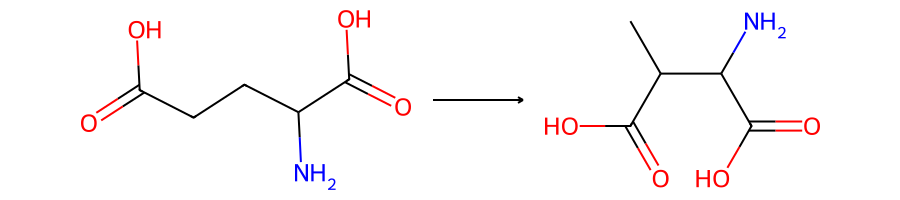

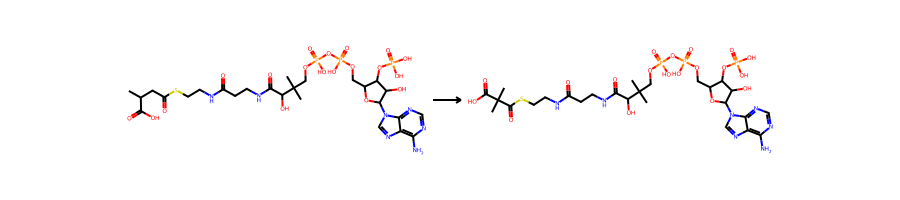

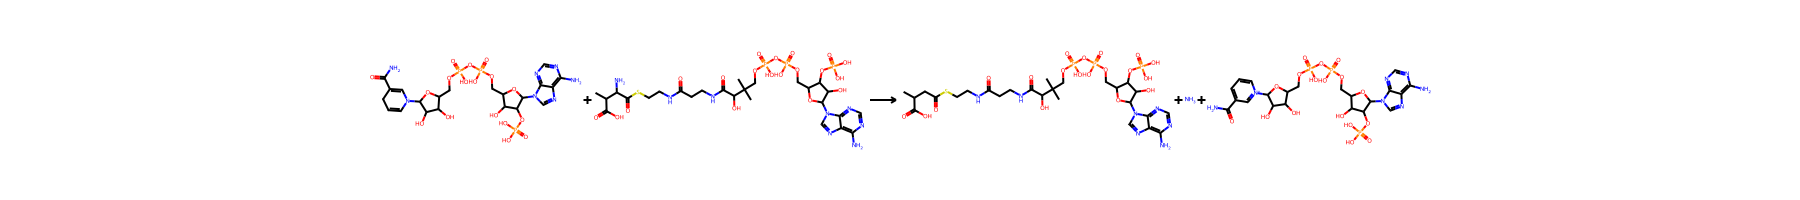

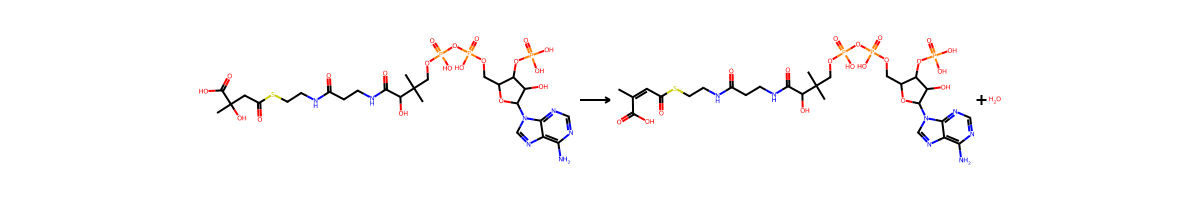

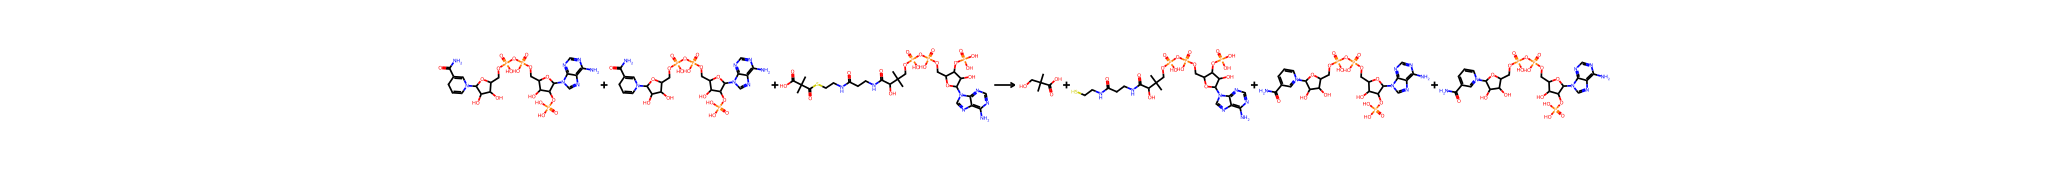

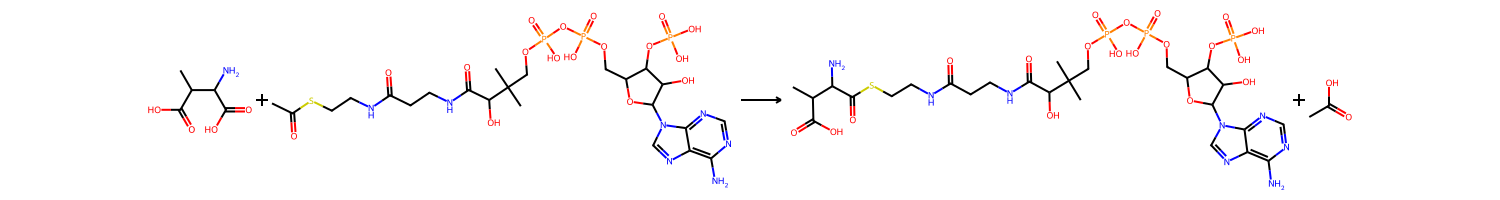

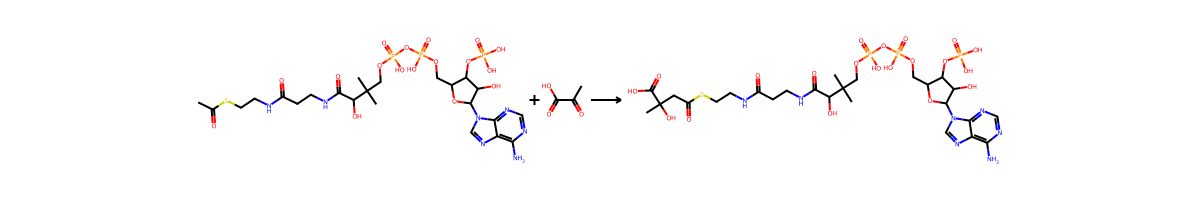

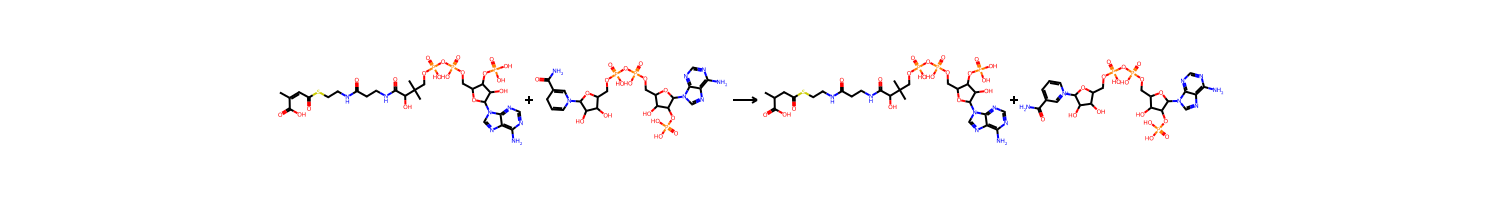

In [18]:
with open('foo.txt', 'w') as f:
    for sma in r['am_smarts']:
        lhl, rhl = de_am(sma)
        de_am_sma = f"{".".join(lhl)}>>{".".join(rhl)}"
        f.write(f"{de_am_sma}\n")

        display(SVG(draw_reaction(de_am_sma)))

9c2c777c0fea421a26efc26857522fd2ccce1555


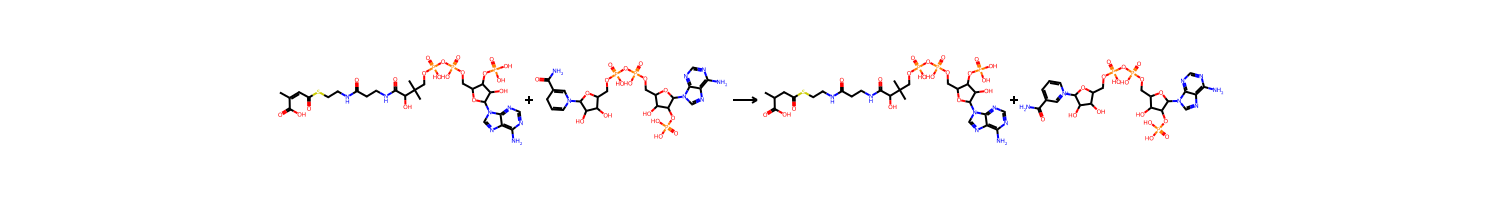

e86048734a2f69f1257bd92b62ddb418a781fe98


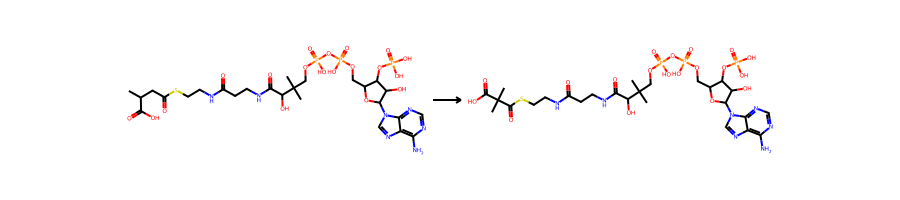

62277981d883290bf5c0d4ed25855547d908a0b4


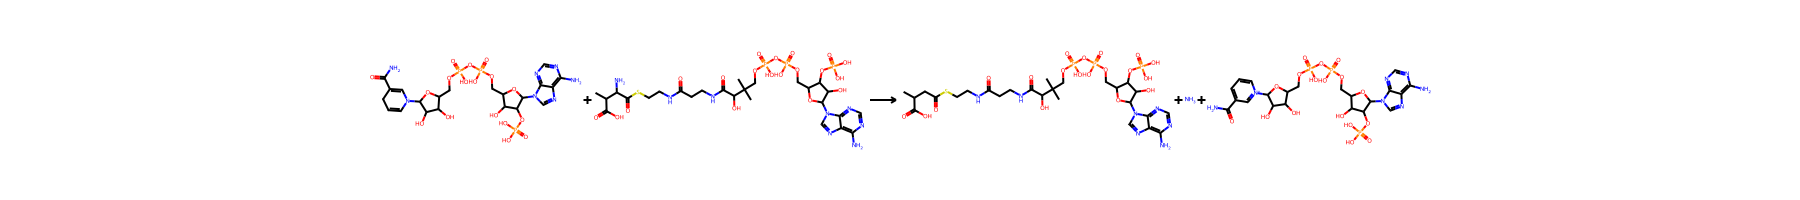

5582845919356f447668dd0ea4647fbddf01b7ac


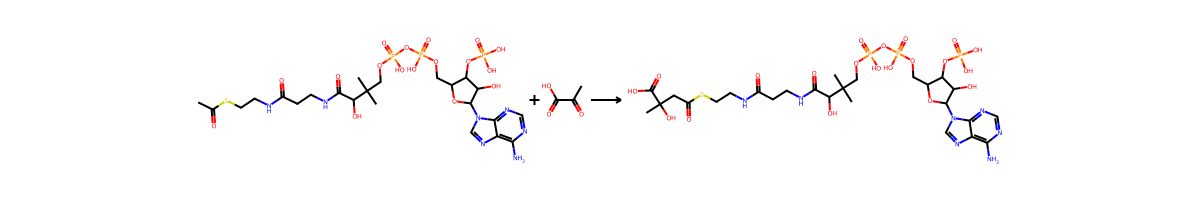

bd616dde067e2786bec3a4ea2c6e17d2d299dce4


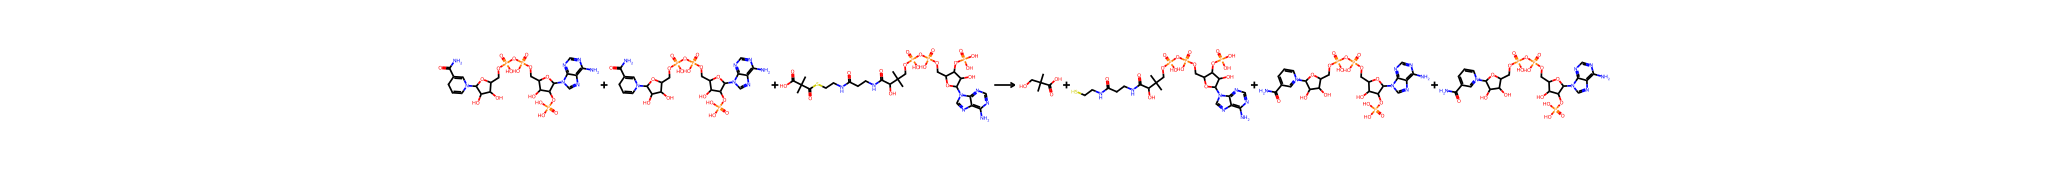

In [38]:
rxns_to_add = ['CC(=CC(=O)SCCNC(=O)CCNC(=O)C(O)C(C)(C)COP(=O)(O)OP(=O)(O)OCC1OC(n2cnc3c(N)ncnc32)C(O)C1OP(=O)(O)O)C(=O)O.NC(=O)C1=CN(C2OC(COP(=O)(O)OP(=O)(O)OCC3OC(n4cnc5c(N)ncnc54)C(OP(=O)(O)O)C3O)C(O)C2O)C=CC1>>CC(CC(=O)SCCNC(=O)CCNC(=O)C(O)C(C)(C)COP(=O)(O)OP(=O)(O)OCC1OC(n2cnc3c(N)ncnc32)C(O)C1OP(=O)(O)O)C(=O)O.NC(=O)c1ccc[n+](C2OC(COP(=O)(O)OP(=O)(O)OCC3OC(n4cnc5c(N)ncnc54)C(OP(=O)(O)O)C3O)C(O)C2O)c1', 'CC(CC(=O)SCCNC(=O)CCNC(=O)C(O)C(C)(C)COP(=O)(O)OP(=O)(O)OCC1OC(n2cnc3c(N)ncnc32)C(O)C1OP(=O)(O)O)C(=O)O>>CC(C)(C(=O)O)C(=O)SCCNC(=O)CCNC(=O)C(O)C(C)(C)COP(=O)(O)OP(=O)(O)OCC1OC(n2cnc3c(N)ncnc32)C(O)C1OP(=O)(O)O', 'NC(=O)C1=CN(C2OC(COP(=O)(O)OP(=O)(O)OCC3OC(n4cnc5c(N)ncnc54)C(OP(=O)(O)O)C3O)C(O)C2O)C=CC1.CC(C(=O)O)C(N)C(=O)SCCNC(=O)CCNC(=O)C(O)C(C)(C)COP(=O)(O)OP(=O)(O)OCC1OC(n2cnc3c(N)ncnc32)C(O)C1OP(=O)(O)O>>CC(CC(=O)SCCNC(=O)CCNC(=O)C(O)C(C)(C)COP(=O)(O)OP(=O)(O)OCC1OC(n2cnc3c(N)ncnc32)C(O)C1OP(=O)(O)O)C(=O)O.N.NC(=O)c1ccc[n+](C2OC(COP(=O)(O)OP(=O)(O)OCC3OC(n4cnc5c(N)ncnc54)C(OP(=O)(O)O)C3O)C(O)C2O)c1', 'CC(=O)SCCNC(=O)CCNC(=O)C(O)C(C)(C)COP(=O)(O)OP(=O)(O)OCC1OC(n2cnc3c(N)ncnc32)C(O)C1OP(=O)(O)O.CC(=O)C(=O)O>>CC(O)(CC(=O)SCCNC(=O)CCNC(=O)C(O)C(C)(C)COP(=O)(O)OP(=O)(O)OCC1OC(n2cnc3c(N)ncnc32)C(O)C1OP(=O)(O)O)C(=O)O', 'NC(=O)C1=CN(C2OC(COP(=O)(O)OP(=O)(O)OCC3OC(n4cnc5c(N)ncnc54)C(OP(=O)(O)O)C3O)C(O)C2O)C=CC1.NC(=O)C1=CN(C2OC(COP(=O)(O)OP(=O)(O)OCC3OC(n4cnc5c(N)ncnc54)C(OP(=O)(O)O)C3O)C(O)C2O)C=CC1.CC(C)(C(=O)O)C(=O)SCCNC(=O)CCNC(=O)C(O)C(C)(C)COP(=O)(O)OP(=O)(O)OCC1OC(n2cnc3c(N)ncnc32)C(O)C1OP(=O)(O)O>>CC(C)(CO)C(=O)O.CC(C)(COP(=O)(O)OP(=O)(O)OCC1OC(n2cnc3c(N)ncnc32)C(O)C1OP(=O)(O)O)C(O)C(=O)NCCC(=O)NCCS.NC(=O)c1ccc[n+](C2OC(COP(=O)(O)OP(=O)(O)OCC3OC(n4cnc5c(N)ncnc54)C(OP(=O)(O)O)C3O)C(O)C2O)c1.NC(=O)c1ccc[n+](C2OC(COP(=O)(O)OP(=O)(O)OCC3OC(n4cnc5c(N)ncnc54)C(OP(=O)(O)O)C3O)C(O)C2O)c1']
for elt in rxns_to_add:
    rid = hash_reaction(elt)
    print(rid)
    display(SVG(draw_reaction(elt)))

In [17]:
r['half_expansion'] = 'forward'

In [20]:
r = r.loc[:, ['smarts', 'am_smarts', 'rules', 'half_expansion', 'size']]

In [12]:
c = pd.read_parquet(f'{dir}/compounds.parquet')
c.head()

,id,smiles,type,name
0,fae11404b12230ded37cfd2511bf3dd98bdacd3c,O=C(O)CCC(=O)O,source,succinate
1,55e7ca03fb953e89747496916800481ee5f52b4a,O=C(O)C=CC(=O)O,source,fumarate
2,77d21e11cc906a4c9614c97db30147761a24e690,O=C(O)CC(O)C(=O)O,source,malate
3,20e696beb1325772afccb7eb1d2c187c70696753,O=C(O)CC(=O)C(=O)O,source,oxaloacetate
4,6cf6db1d70f43061de31deeb417214c6fd7ad005,O=C(O)CCC(=O)C(=O)O,source,ketoglutarate


In [13]:
c.loc[c['type'] == 'source']

,id,smiles,type,name
0,fae11404b12230ded37cfd2511bf3dd98bdacd3c,O=C(O)CCC(=O)O,source,succinate
1,55e7ca03fb953e89747496916800481ee5f52b4a,O=C(O)C=CC(=O)O,source,fumarate
2,77d21e11cc906a4c9614c97db30147761a24e690,O=C(O)CC(O)C(=O)O,source,malate
3,20e696beb1325772afccb7eb1d2c187c70696753,O=C(O)CC(=O)C(=O)O,source,oxaloacetate
4,6cf6db1d70f43061de31deeb417214c6fd7ad005,O=C(O)CCC(=O)C(=O)O,source,ketoglutarate
5,18fadf6d3e42e06b2a32e2f706d8769770ba95ca,O=C(O)CC(O)(CC(=O)O)C(=O)O,source,citrate
6,2efe03c1b1595e5fedce6a3674dad82075142215,CC(=O)C(=O)O,source,pyruvate
7,6a2307f86745c292bc504cdf358769d6ed6f1136,CC(=O)O,source,acetate
8,173558aa0ed72d2e42e1bc71880f594c0e67dbea,CC(N)C(=O)O,source,alanine
9,253f3dd358a3fbf58c834308fb8340e053ed076f,NC(N)=NCCCC(N)C(=O)O,source,arginine


In [10]:
helpers = pd.read_parquet(
    '/home/stef/quest_data/bottle/data/interim/expansions/5_steps_ccm_aa_to_bottle_targets_25_combo_mechinferred_dt_13_and_mechinferred_dt_04_rules/compounds.parquet'
)
helpers = helpers.loc[helpers['type'] == 'helper']
helper_ids = helpers['id'].to_list()
helpers.head()

,id,smiles,type,name
947,07e48b419b37606b338ba3e838a8e5f56e1cef31,Nc1ncnc2c1ncn2C1OC(COP(=O)(O)OP(=O)(O)OP(=O)(O...,helper,PYROPHOSPHATE_DONOR_CoF
948,4ea34a41c2091b9cd312119934909d0fb3217dc8,Nc1ncnc2c1ncn2C1OC(COP(=O)(O)O)C(O)C1O,helper,PYROPHOSPHATE_ACCEPTOR_CoF
949,c1a94434194999200be197465c01c3cfd85387e8,Cc1cc2nc3c(=O)[nH]c(=O)nc-3n(CC(O)C(O)C(O)COP(...,helper,FAD_CoF
950,37225a49e3ed17e65590fb5ed4d5361bad9a6832,Cc1cc2c(cc1C)N(CC(O)C(O)C(O)COP(=O)(O)OP(=O)(O...,helper,FADH2_CoF
951,d149421ac53cc62325e84c1688210e5ba639cbaf,Nc1ncnc2c1ncn2C1OC(COP(=O)(O)OP(=O)(O)O)C(O)C1O,helper,PHOSPHATE_ACCEPTOR_CoF


In [11]:
c.loc[c['id'].isin(helper_ids), 'type'] = 'helper'

In [12]:
c.loc[c['type'] == 'helper']

,id,smiles,type,name
484,07e48b419b37606b338ba3e838a8e5f56e1cef31,Nc1ncnc2c1ncn2C1OC(COP(=O)(O)OP(=O)(O)OP(=O)(O...,helper,PYROPHOSPHATE_DONOR_CoF
485,4ea34a41c2091b9cd312119934909d0fb3217dc8,Nc1ncnc2c1ncn2C1OC(COP(=O)(O)O)C(O)C1O,helper,PYROPHOSPHATE_ACCEPTOR_CoF
486,c1a94434194999200be197465c01c3cfd85387e8,Cc1cc2nc3c(=O)[nH]c(=O)nc-3n(CC(O)C(O)C(O)COP(...,helper,FAD_CoF
487,37225a49e3ed17e65590fb5ed4d5361bad9a6832,Cc1cc2c(cc1C)N(CC(O)C(O)C(O)COP(=O)(O)OP(=O)(O...,helper,FADH2_CoF
488,d149421ac53cc62325e84c1688210e5ba639cbaf,Nc1ncnc2c1ncn2C1OC(COP(=O)(O)OP(=O)(O)O)C(O)C1O,helper,PHOSPHATE_ACCEPTOR_CoF
489,da7b7aacec3c6f733a01920b971ac0deda5d3303,NC(=O)c1ccc[n+](C2OC(COP(=O)(O)OP(=O)(O)OCC3OC...,helper,NAD_CoF
490,27e471428018c3779a1b13dec34fcbc3d80f6c28,NC(=O)C1=CN(C2OC(COP(=O)(O)OP(=O)(O)OCC3OC(n4c...,helper,NADH_CoF
491,22b2fef9ba937f5043e7bdcfe21ac099484e7a18,Nc1ncnc2c1ncn2C1OC(COP(=O)(O)OS(=O)(=O)O)C(OP(...,helper,SULFATE_DONOR_CoF
492,2b0e5bb488095312f97216bdfc68bcfcf26949e4,Nc1ncnc2c1ncn2C1OC(COP(=O)(O)O)C(OP(=O)(O)O)C1O,helper,SULFATE_ACCEPTOR_CoF
493,e6490b8cb18f68ed72b12d82460b1384c017d3c6,C[S+](CCC(N)C(=O)O)CC1OC(n2cnc3c(N)ncnc32)C(O)C1O,helper,METHYL_DONOR_CoF


In [34]:
kcs = pd.read_parquet(
    "../artifacts/known/known_compounds.parquet"
)
kcs.head()

,id,smiles,name,chebi_id,n_atoms
0,df58248c414f342c81e056b40bee12d17a08bf61,*,A,CHEBI:13193,1
1,bc2f74c22f98f7b6ffbc2f67453dbfa99bce9a32,**,RX,CHEBI:17792,2
2,e8ecd17bfc980925ff0b634bd13104c09dc4591f,*C,an alkane,CHEBI:18310,2
3,b219689f21c828e7f057ef453af1187baa98fbf3,*C#N,a nitrile,CHEBI:18379,3
4,94295b0379859ca57b86c85b0768526c711fe762,*C(*)(O)C(*)(*)O,an ethanediol,CHEBI:140594,8


In [35]:
kc_smi2name = dict(zip(kcs['smiles'], kcs['name'].to_list()))

In [36]:
c.loc[c['type'] == 'known', 'name'] = c.loc[c['type'] == 'known', 'smiles'].map(kc_smi2name)
c.head()

,id,smiles,type,name
0,fae11404b12230ded37cfd2511bf3dd98bdacd3c,O=C(O)CCC(=O)O,source,succinate
1,55e7ca03fb953e89747496916800481ee5f52b4a,O=C(O)C=CC(=O)O,source,fumarate
2,77d21e11cc906a4c9614c97db30147761a24e690,O=C(O)CC(O)C(=O)O,source,malate
3,20e696beb1325772afccb7eb1d2c187c70696753,O=C(O)CC(=O)C(=O)O,source,oxaloacetate
4,6cf6db1d70f43061de31deeb417214c6fd7ad005,O=C(O)CCC(=O)C(=O)O,source,ketoglutarate


In [37]:
c.loc[c['type'] == 'target']


,id,smiles,type,name
29,6569ea8ebe9fdd8627adb76f7d942dbbbb83c56d,CC(C)(CO)C(=O)O,target,3hpa
30,b4419ef13b0e2ce0034b0dfb2bda3aafe2afc298,CC(O)C(C)(C)C(=O)O,target,dmhb


In [13]:
import polars as pl

In [14]:
c = pl.from_pandas(c)
c.head()

id,smiles,type,name
str,str,cat,str
"""fae11404b12230ded37cfd2511bf3d…","""O=C(O)CCC(=O)O""","""source""","""succinate"""
"""55e7ca03fb953e8974749691680048…","""O=C(O)C=CC(=O)O""","""source""","""fumarate"""
"""77d21e11cc906a4c9614c97db30147…","""O=C(O)CC(O)C(=O)O""","""source""","""malate"""
"""20e696beb1325772afccb7eb1d2c18…","""O=C(O)CC(=O)C(=O)O""","""source""","""oxaloacetate"""
"""6cf6db1d70f43061de31deeb417214…","""O=C(O)CCC(=O)C(=O)O""","""source""","""ketoglutarate"""


In [40]:
dir

'/home/stef/quest_data/bottle/data/interim/expansions/5_steps_ccm_aa_to_bottle_targets_25_combo_mechinferred_dt_13_and_mechinferred_dt_04_rules'

In [15]:
c.write_parquet(dir + '/compounds.parquet')

In [21]:
r.head()

,smarts,am_smarts,rules,half_expansion,size
0,NC(CCC(=O)O)C(=O)O>>CC(C(=O)O)C(N)C(=O)O,[NH2:1][CH:2]([CH2:3][CH2:4][C:5](=[O:6])[OH:7...,[mechinferred_dt_13:5008],forward,9
1,CC(CC(=O)SCCNC(=O)CCNC(=O)C(O)C(C)(C)COP(=O)(O...,[CH3:3][CH:2]([CH2:1][C:7](=[O:8])[S:9][CH2:10...,[mechinferred_dt_04:3939],forward,5
2,NC(=O)C1=CN(C2OC(COP(=O)(O)OP(=O)(O)OCC3OC(n4c...,[NH2:58][C:59](=[O:60])[C:61]1=[CH:105][N:65](...,[mechinferred_dt_04:6695],forward,15
3,CC(O)(CC(=O)SCCNC(=O)CCNC(=O)C(O)C(C)(C)COP(=O...,[CH3:1][C:2]([OH:3])([CH2:4][C:5](=[O:6])[S:7]...,"[mechinferred_dt_13:2441, mechinferred_dt_13:9...",forward,8
4,NC(=O)C1=CN(C2OC(COP(=O)(O)OP(=O)(O)OCC3OC(n4c...,[NH2:105][C:106](=[O:107])[C:108]1=[CH:152][N:...,"[mechinferred_dt_04:4272, mechinferred_dt_04:1...",forward,26


In [22]:
r = pl.from_pandas(r)
r.write_parquet(dir + '/am_rxns.parquet')

In [16]:
gens = pl.DataFrame(
    {
        "half_expansion": ['forward', 'retro'],
        "generation": [5, 0],
    }
)
gens.write_csv(dir + '/generations.csv')

In [46]:
dir

'/home/stef/quest_data/bottle/data/interim/expansions/5_steps_ccm_aa_to_bottle_targets_25_combo_mechinferred_dt_13_and_mechinferred_dt_04_rules'